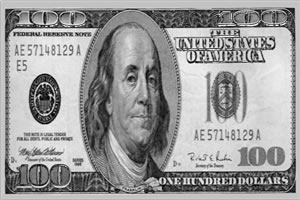

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img=cv2.imread("/content/img.bmp",0)

cv2_imshow(img)

In [54]:
arr=np.array(img)
arr.shape

(200, 300)

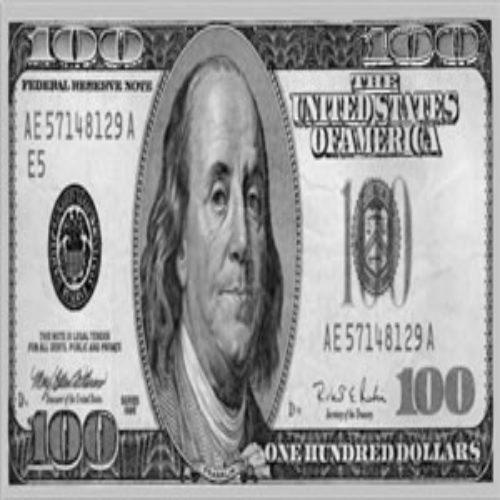

(500, 500)

In [55]:
img_resize = cv2.resize(img,(500,500))
cv2_imshow(img_resize)
img_resize.shape

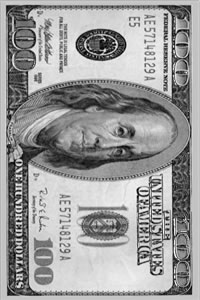

In [56]:
img_rotated=cv2.rotate(img,cv2.ROTATE_90_CLOCKWISE)
cv2_imshow(img_rotated)


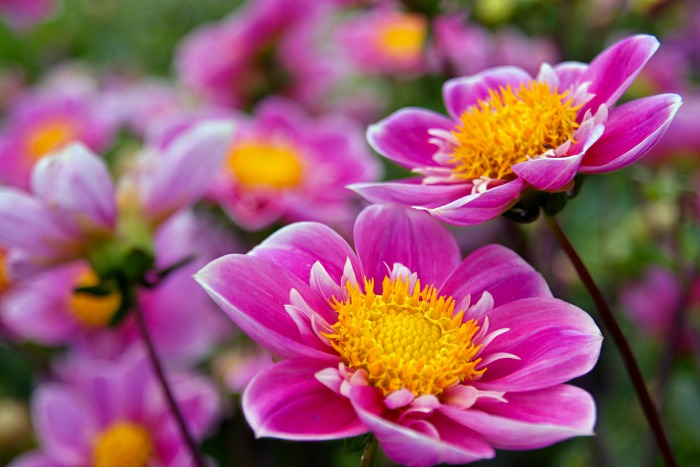

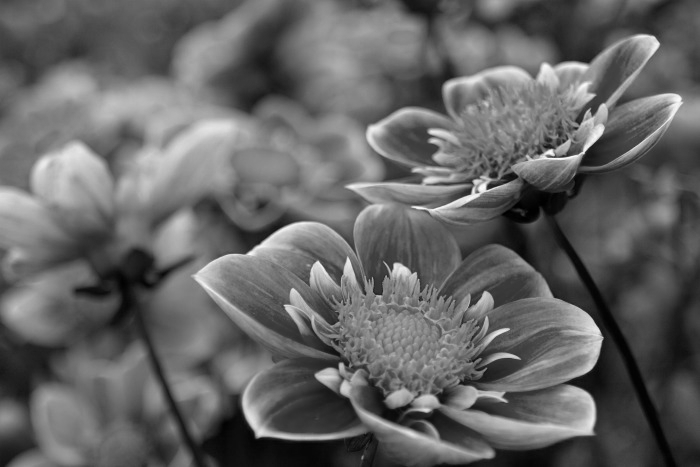

In [57]:
img_cvt=cv2.imread("/content/lavender.jpg",1)
cv2_imshow(img_cvt)

img_gray=cv2.cvtColor(img_cvt,cv2.COLOR_RGB2GRAY)
cv2_imshow(img_gray)

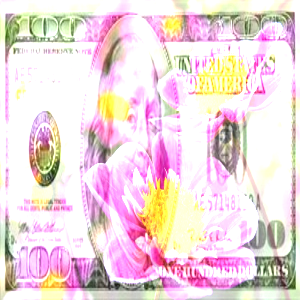

In [58]:
img_1=cv2.imread("/content/img.bmp",1)
img_resize_1 = cv2.resize(img_1,(300,300))

img_2=cv2.imread("/content/lavender.jpg",1)
img_resize_2 = cv2.resize(img_2,(300,300))

image_add=cv2.add(img_resize_1,img_resize_2)
cv2_imshow(image_add)



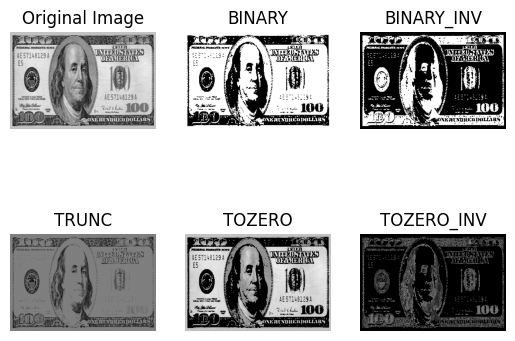

In [59]:
ret,thresh1=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2=cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3=cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4=cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5=cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles=['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images=[img, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i],cmap='gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.axis("off")
plt.show()

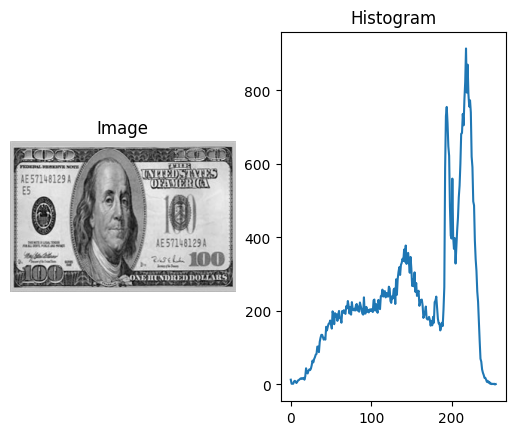

In [60]:
hist=cv2.calcHist([img],[0],None,[256],[0,256])

plt.subplot(1,2,1),
plt.imshow(img,'gray')
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2),
plt.plot(hist)
plt.title("Histogram")
plt.show()

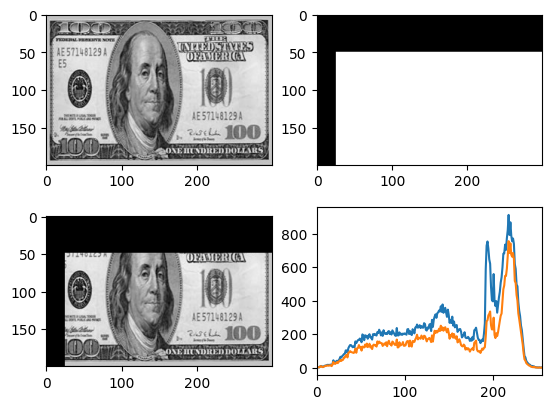

In [62]:
mask=np.zeros(img.shape, np.uint8)
mask[50:300,25:350] = 255
masked_img=cv2.bitwise_and(img,img,mask = mask)

# Calculate histogram with mask and without mask
# Check third argument for mask

hist_full=cv2.calcHist([img],[0],None,[256],[0,256])
hist_mask=cv2.calcHist([img],[0],mask,[256],[0,256])

plt.subplot(2,2,1),
plt.imshow(img, 'gray')

plt.subplot(2,2,2),
plt.imshow(mask,'gray')

plt.subplot(2,2,3),
plt.imshow(masked_img, 'gray')

plt.subplot(2,2,4),
plt.plot(hist_full), plt.plot(hist_mask)
plt.xlim([0,256])

plt.show()

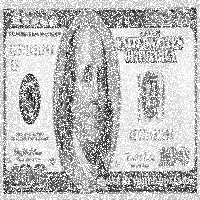

In [65]:
# Generate random Gaussian noise
mean=0
stddev=180
img=cv2.resize(img,(200,200))
noise=np.zeros(img.shape,np.uint8)
noise=cv2.randn(noise,mean,stddev)

# Add noise to image
noise_img=cv2.add(img,noise)
cv2_imshow(noise_img)